#Project 2 Pluto Academy

# Titanic Survival Prediction

**Dataset:** Titanic
**Task:** Binary Classification — Predict passenger survival (0 = No, 1 = Yes)  
**Models Compared:** Logistic Regression, Random Forest, K-Nearest Neighbors  


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Styling
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.labelcolor':  '#e0e0e0',
    'axes.titlecolor':  '#ffffff',
    'axes.edgecolor':   '#3d3d5c',
    'xtick.color':      '#b0b0c0',
    'ytick.color':      '#b0b0c0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2d2d4e',
    'grid.alpha':       0.5,
    'figure.dpi':       120,
    'font.family':      'DejaVu Sans',
})
PALETTE = ['#7c5cbf', '#4ecdc4', '#ff6b6b', '#ffe66d', '#a8e6cf']
print("Libraries loaded.")

Libraries loaded.


In [5]:
df = pd.read_csv('train.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.shape

(891, 12)

Unique Values

In [7]:
info_df = pd.DataFrame({
    'dtype':    df.dtypes,
    'non_null': df.count(),
    'missing':  df.isnull().sum(),
    'missing%': (df.isnull().sum() / len(df) * 100).round(2),
    'unique':   df.nunique()
})
print('\n Column-level summary ')
display(info_df)


 Column-level summary 


,dtype,non_null,missing,missing%,unique
PassengerId,int64,891,0,0.00,891
Survived,int64,891,0,0.00,2
Pclass,int64,891,0,0.00,3
Name,object,891,0,0.00,891
Sex,object,891,0,0.00,2
Age,float64,714,177,19.87,88
SibSp,int64,891,0,0.00,7
Parch,int64,891,0,0.00,7
Ticket,object,891,0,0.00,681
Fare,float64,891,0,0.00,248


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


 Target Distribution

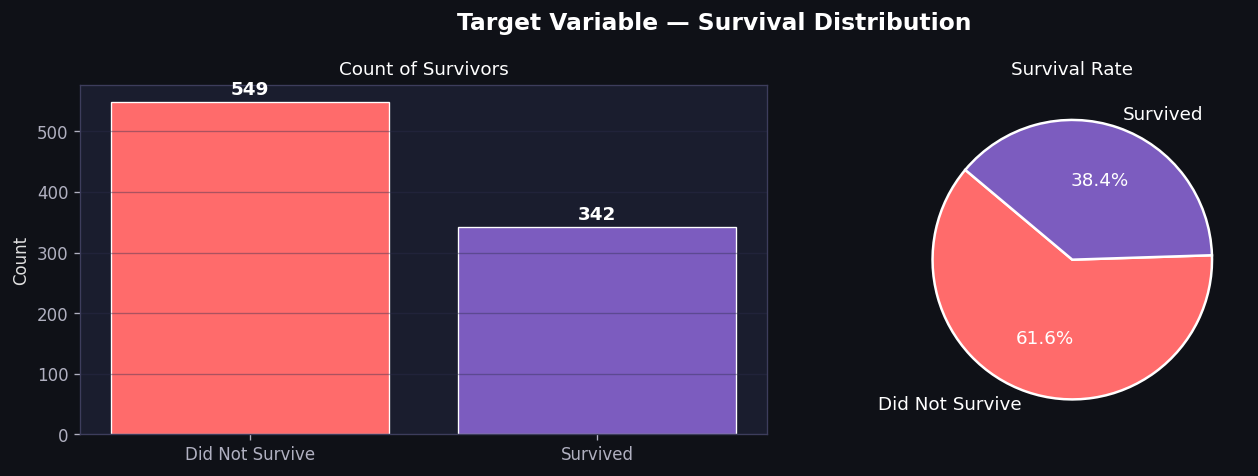

Survival rate: 38.4%  |  Class imbalance ratio ≈ 1:1.61


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable — Survival Distribution', fontsize=14, fontweight='bold', color='white')

# Count plot
counts = df['Survived'].value_counts()
bars = axes[0].bar(['Did Not Survive', 'Survived'], counts.values,
                   color=[PALETTE[2], PALETTE[0]], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold', color='white')
axes[0].set_title('Count of Survivors', fontsize=11)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
axes[0].grid(axis='y', alpha=0.4)

# Pie chart
axes[1].pie(counts.values, labels=['Did Not Survive', 'Survived'],
            colors=[PALETTE[2], PALETTE[0]], autopct='%1.1f%%',
            startangle=140, textprops={'color': 'white', 'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Survival Rate', fontsize=11)

plt.tight_layout()
plt.show()

survival_rate = counts[1] / counts.sum() * 100
print(f'Survival rate: {survival_rate:.1f}%  |  Class imbalance ratio ≈ 1:{counts[0]/counts[1]:.2f}')

 Missing Values

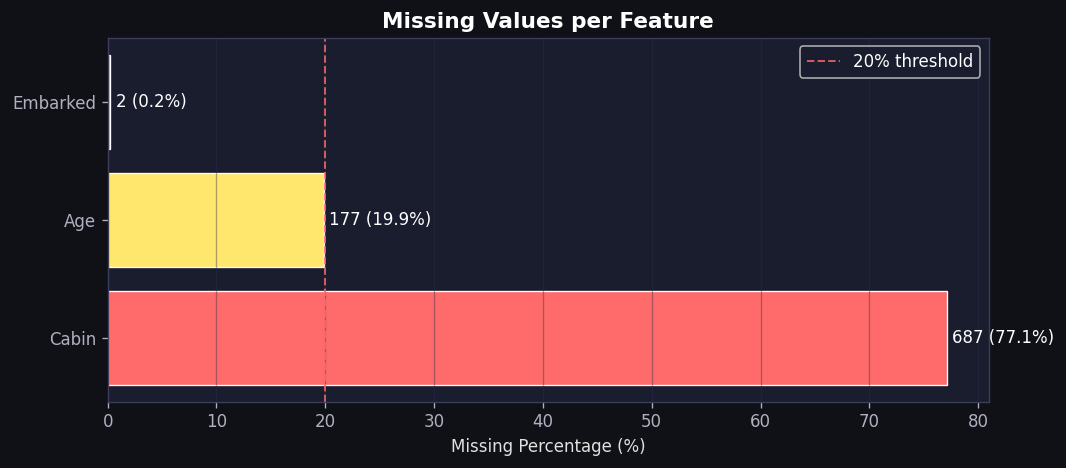

In [10]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing.index, missing.values / len(df) * 100,
               color=[PALETTE[2], PALETTE[3], PALETTE[4]], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=10, color='white')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values per Feature', fontsize=13, fontweight='bold')
ax.axvline(20, color='#ff6b6b', linestyle='--', alpha=0.8, linewidth=1.2, label='20% threshold')
ax.legend(facecolor='#1a1d2e', labelcolor='white')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

### Preprocessing

**Decisions & Reasons for it :**

| Feature | Action | Reason |
|---------|--------|--------|
| Cabin | **Drop** | Around 77% of the values is missing, so it is better to remove this column instead of guessing the missing data. |
| Ticket | **Drop** | The full passenger name was not useful, but titles like Mr., Mrs., and Miss could provide helpful information. |
|`Name | **Drop → Title extracted** | This is only an identification number and has no effect on whether a passenger survived. |
| PassengerId | **Drop** | Arbitrary ID, not a predictor |
| Age | **Median impute by Title group** | Small % missing (20%); group-median reduces bias |
| Embarked | **Mode impute** | Only 2 rows missing |
| Sex , Embarked | **Label encode** | Convert categories to numeric |
| All numeric | **StandardScaler** | LR & KNN are distance/gradient sensitive they work better on numeric data |

In [11]:
def preprocess(data, scaler=None, is_train=True):
    """Full preprocessing pipeline — stateless on test set (scaler passed in)."""
    df_p = data.copy()

    df_p['Title'] = df_p['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    rare_titles = df_p['Title'].value_counts()[df_p['Title'].value_counts() < 10].index
    df_p['Title'] = df_p['Title'].replace(rare_titles, 'Rare')
    df_p['Title'] = df_p['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    df_p['Age'] = df_p.groupby('Title')['Age'].transform(
        lambda x: x.fillna(x.median())
    )

    df_p['Embarked'] = df_p['Embarked'].fillna(df_p['Embarked'].mode()[0])

    df_p['FamilySize']  = df_p['SibSp'] + df_p['Parch'] + 1
    df_p['IsAlone']     = (df_p['FamilySize'] == 1).astype(int)
    df_p['FarePerPerson'] = df_p['Fare'] / df_p['FamilySize']
    df_p['AgeBin']      = pd.cut(df_p['Age'], bins=[0, 12, 18, 35, 60, 100],
                                  labels=[0, 1, 2, 3, 4]).astype(int)

    #Drop irrelevant columns
    df_p.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

    #Encode categoricals
    le_sex  = LabelEncoder().fit(['female', 'male'])
    le_emb  = LabelEncoder().fit(['C', 'Q', 'S'])
    le_title = LabelEncoder()
    df_p['Sex']      = le_sex.transform(df_p['Sex'])
    df_p['Embarked'] = le_emb.transform(df_p['Embarked'])
    df_p['Title']    = le_title.fit_transform(df_p['Title'])

    return df_p


df_clean = preprocess(df)
print('Cleaned shape:', df_clean.shape)
print('Remaining nulls:', df_clean.isnull().sum().sum())
df_clean.head(3)

Cleaned shape: (891, 13)
Remaining nulls: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,FarePerPerson,AgeBin
0,0,3,1,22.0,1,0,7.2500,2,2,2,0,3.62500,2
1,1,1,0,38.0,1,0,71.2833,0,3,2,0,35.64165,3
2,1,3,0,26.0,0,0,7.9250,2,1,1,1,7.92500,2


Train Test Split

In [12]:
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Class balance in training  → {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Class balance in test      → {y_test.value_counts(normalize=True).round(3).to_dict()}')

Training set : 712 samples
Test set     : 179 samples
Class balance in training  → {0: 0.617, 1: 0.383}
Class balance in test      → {0: 0.615, 1: 0.385}


###  Feature Scaling

**Why Feature Scaling?**

###### Feature scaling is applied to make sure that all numerical features are on a similar scale. This is especially important for models like **Logistic Regression** and **K-Nearest Neighbors (KNN)** because they are affected by the size of the feature values. Although **Random Forest** does not require feature scaling, the same scaling process is applied to all models to ensure a fair and consistent comparison of their performance.


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling complete. Feature means (train) ~', np.round(X_train_scaled.mean(axis=0), 3))

Scaling complete. Feature means (train) ~ [-0. -0.  0. -0. -0. -0.  0. -0.  0.  0.  0. -0.]


Correlation Heatmap

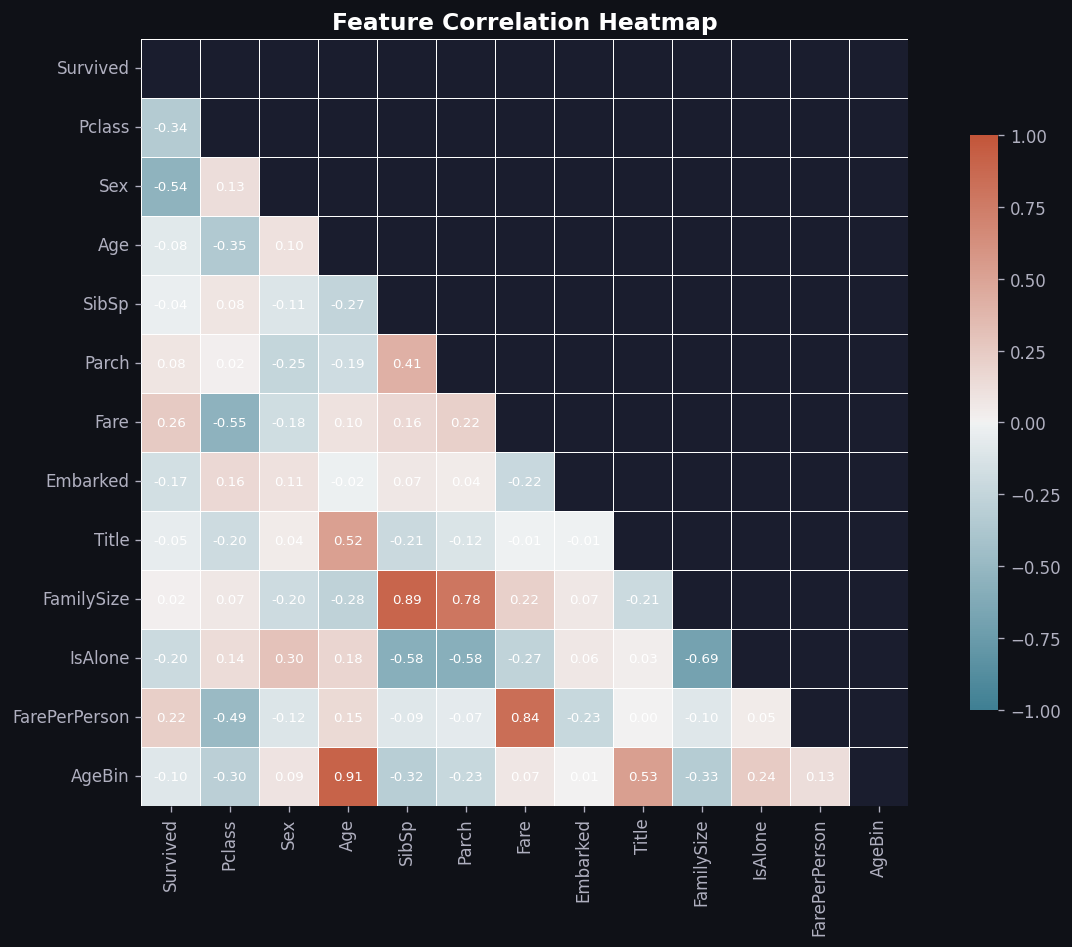

In [14]:
fig, ax = plt.subplots(figsize=(11, 8))
corr = df_clean.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=0.5, annot=True, fmt='.2f',
            annot_kws={'size': 8, 'color': 'white'}, ax=ax,
            cbar_kws={'shrink': 0.75})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Random Forest

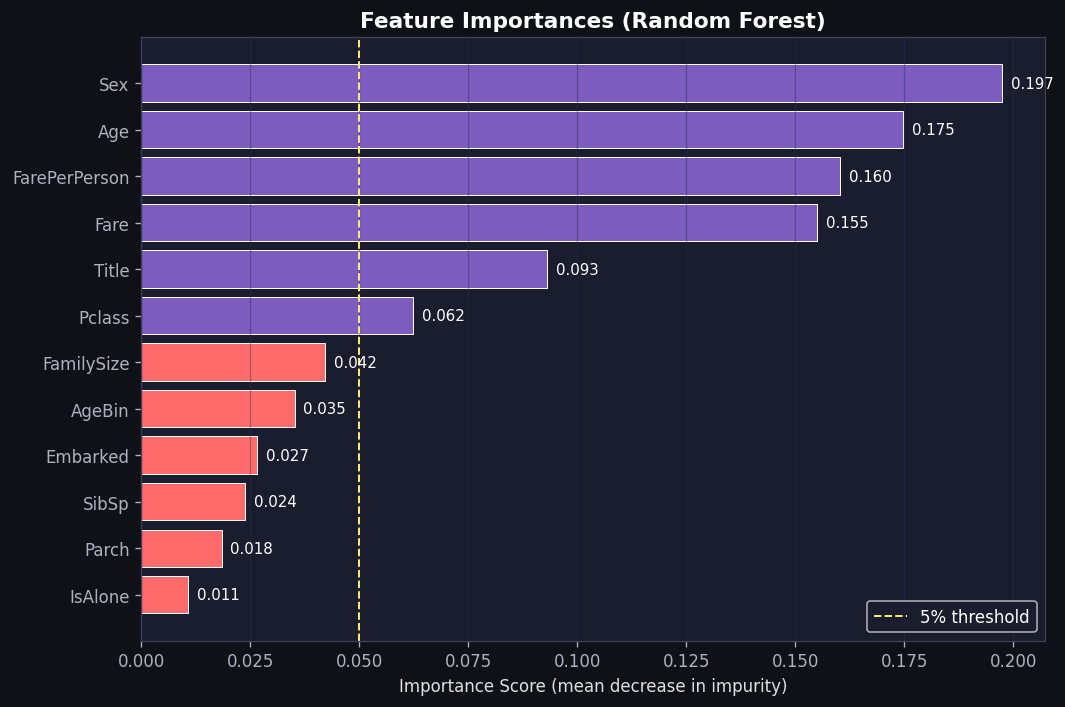

 Feature Importances 
Sex              0.197430
Age              0.174676
FarePerPerson    0.160288
Fare             0.155005
Title            0.093149
Pclass           0.062296
FamilySize       0.042217
AgeBin           0.035168
Embarked         0.026636
SibSp            0.023888
Parch            0.018474
IsAlone          0.010773


In [16]:
rf_fi = RandomForestClassifier(n_estimators=300, random_state=42)
rf_fi.fit(X_train_scaled, y_train)

fi = pd.Series(rf_fi.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = [PALETTE[2] if v < 0.05 else PALETTE[0] for v in fi.values]
bars = ax.barh(fi.index, fi.values, color=colors, edgecolor='white', linewidth=0.6)
ax.axvline(0.05, color='#ffe66d', linestyle='--', linewidth=1.2, label='5% threshold')
for bar, val in zip(bars, fi.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='white')
ax.set_title('Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (mean decrease in impurity)')
ax.legend(facecolor='#1a1d2e', labelcolor='white')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

print(' Feature Importances ')
print(fi.sort_values(ascending=False).to_string())

 Key Features

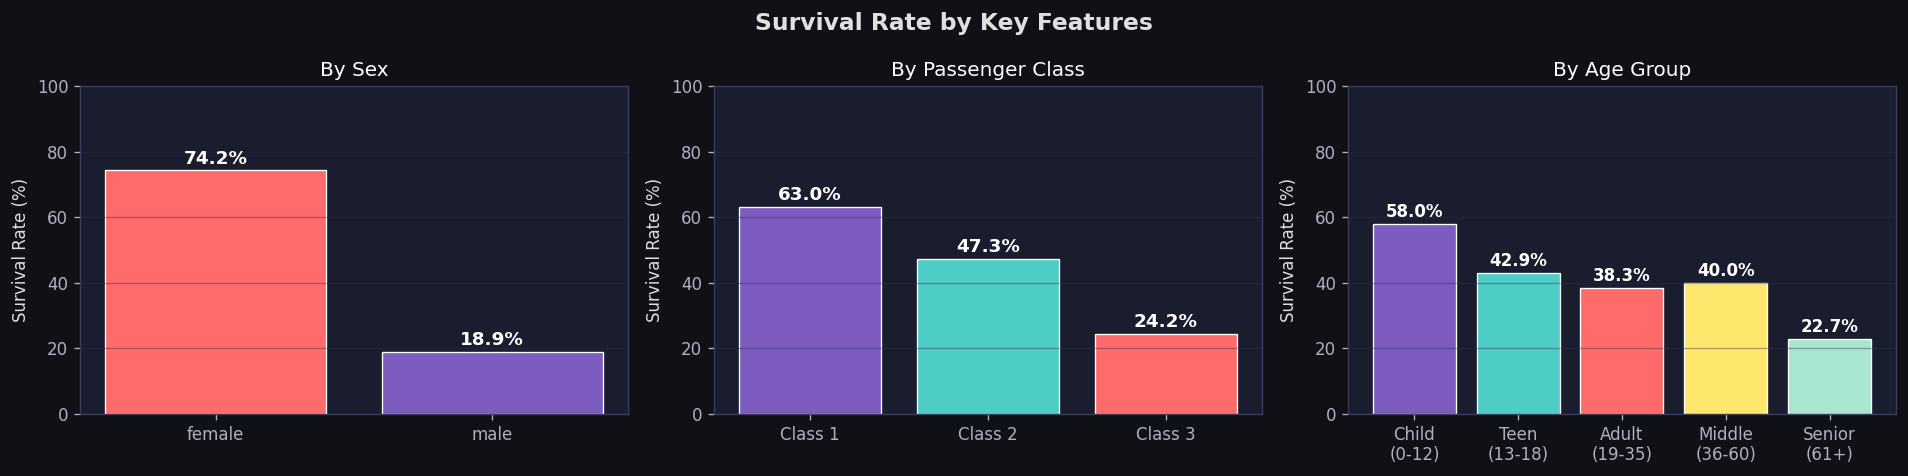

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Survival Rate by Key Features', fontsize=14, fontweight='bold')

sex_surv = df.groupby('Sex')['Survived'].mean() * 100
axes[0].bar(sex_surv.index, sex_surv.values, color=[PALETTE[2], PALETTE[0]], edgecolor='white', linewidth=0.8)
for i, (_, val) in enumerate(sex_surv.items()):
    axes[0].text(i, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=11, color='white', fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].set_title('By Sex')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].grid(axis='y', alpha=0.4)

# Pclass
class_surv = df.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar([f'Class {c}' for c in class_surv.index], class_surv.values,
            color=PALETTE[:3], edgecolor='white', linewidth=0.8)
for i, (_, val) in enumerate(class_surv.items()):
    axes[1].text(i, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=11, color='white', fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].set_title('By Passenger Class')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].grid(axis='y', alpha=0.4)

# Age
df_temp = df.copy()
df_temp['AgeBin'] = pd.cut(df_temp['Age'], bins=[0,12,18,35,60,100],
                            labels=['Child\n(0-12)', 'Teen\n(13-18)', 'Adult\n(19-35)',
                                    'Middle\n(36-60)', 'Senior\n(61+)'])
age_surv = df_temp.groupby('AgeBin')['Survived'].mean() * 100
axes[2].bar(age_surv.index, age_surv.values, color=PALETTE, edgecolor='white', linewidth=0.8)
for i, (_, val) in enumerate(age_surv.items()):
    axes[2].text(i, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')
axes[2].set_ylim(0, 100)
axes[2].set_title('By Age Group')
axes[2].set_ylabel('Survival Rate (%)')
axes[2].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

** Feature Engineering Decisions:**

| New Feature | Derivation | Rationale |
|-------------|------------|----------|
| `Title` | Extracted from `Name` | Encodes social status + age proxy |
| `FamilySize` | `SibSp + Parch + 1` | Larger families had complex evacuation dynamics |
| `IsAlone` | `FamilySize == 1` | Solo travellers had lower survival rates |
| `FarePerPerson` | `Fare / FamilySize` | Normalises fare for group tickets |
| `AgeBin` | Age bucketed to 5 groups | Captures non-linear age effects (children first) |

**Features dropped:** `PassengerId` (ID), `Name` (replaced by Title), `Ticket` (noise), `Cabin` (77% missing)


# Model 1 - Logistic Regression

In [18]:
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_scaled, y_train)

# Cross-validation
cv_lr = cross_val_score(lr, X_train_scaled, y_train, cv=StratifiedKFold(5), scoring='accuracy')
print(f'[Logistic Regression] 5-fold CV Accuracy: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')

[Logistic Regression] 5-fold CV Accuracy: 0.8021 ± 0.0286


### Model 2 · Random Forest

In [19]:
rf = RandomForestClassifier(
    n_estimators=500, max_depth=8, min_samples_split=4,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

cv_rf = cross_val_score(rf, X_train_scaled, y_train, cv=StratifiedKFold(5), scoring='accuracy')
print(f'[Random Forest]       5-fold CV Accuracy: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')

[Random Forest]       5-fold CV Accuracy: 0.8245 ± 0.0253


### Model 3 · K-Nearest Neighbours

Best K: 19  (CV Accuracy: 0.8105)


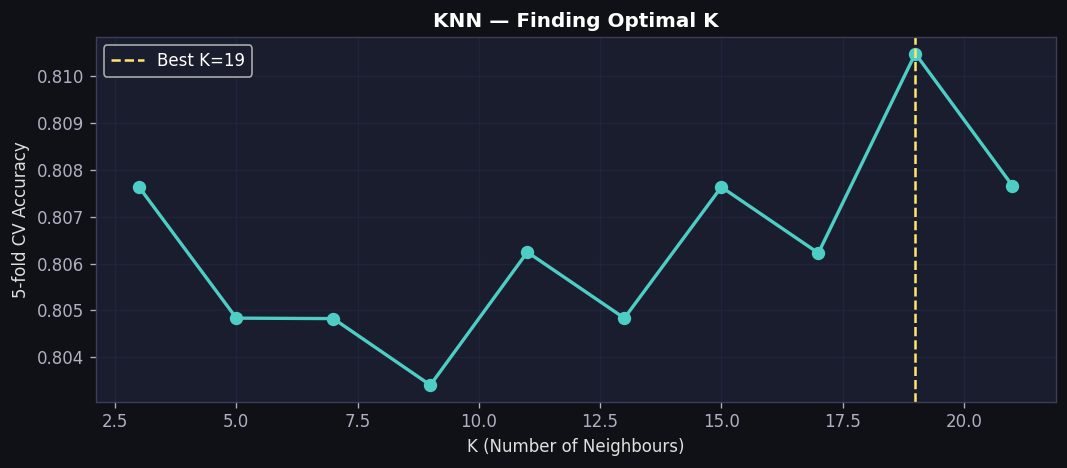

[KNN (K=19)]             5-fold CV Accuracy: 0.8105 ± 0.0298


In [20]:
# optimal K
k_scores = {}
for k in range(3, 22, 2):
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    k_scores[k] = cross_val_score(knn_tmp, X_train_scaled, y_train,
                                   cv=StratifiedKFold(5), scoring='accuracy').mean()

best_k = max(k_scores, key=k_scores.get)
print(f'Best K: {best_k}  (CV Accuracy: {k_scores[best_k]:.4f})')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_scores.keys()), list(k_scores.values()),
        marker='o', color=PALETTE[1], linewidth=2, markersize=7)
ax.axvline(best_k, color=PALETTE[3], linestyle='--', linewidth=1.5, label=f'Best K={best_k}')
ax.set_xlabel('K (Number of Neighbours)')
ax.set_ylabel('5-fold CV Accuracy')
ax.set_title('KNN — Finding Optimal K', fontsize=12, fontweight='bold')
ax.legend(facecolor='#1a1d2e', labelcolor='white')
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

cv_knn = cross_val_score(knn, X_train_scaled, y_train, cv=StratifiedKFold(5), scoring='accuracy')
print(f'[KNN (K={best_k})]             5-fold CV Accuracy: {cv_knn.mean():.4f} ± {cv_knn.std():.4f}')

## Comparing all Models

In [21]:
models = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    f'KNN (K={best_k})':   knn
}

results = []
for name, model in models.items():
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        'CV-Acc':    cross_val_score(model, X_train_scaled, y_train,
                                      cv=StratifiedKFold(5), scoring='accuracy').mean()
    })

results_df = pd.DataFrame(results).set_index('Model')
print('\n Model Performance Comparison ')
display(results_df.style
        .format('{:.4f}')
        .background_gradient(cmap='RdYlGn', axis=0)
        .set_caption('All metrics on hold-out test set (20%)'))


 Model Performance Comparison 


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV-Acc
Model,,,,,,
Logistic Regression,0.8045,0.7833,0.6812,0.7287,0.8661,0.8021
Random Forest,0.8156,0.7903,0.7101,0.7481,0.8473,0.8245
KNN (K=19),0.8268,0.7879,0.7536,0.7704,0.8567,0.8105


Visual Comparison

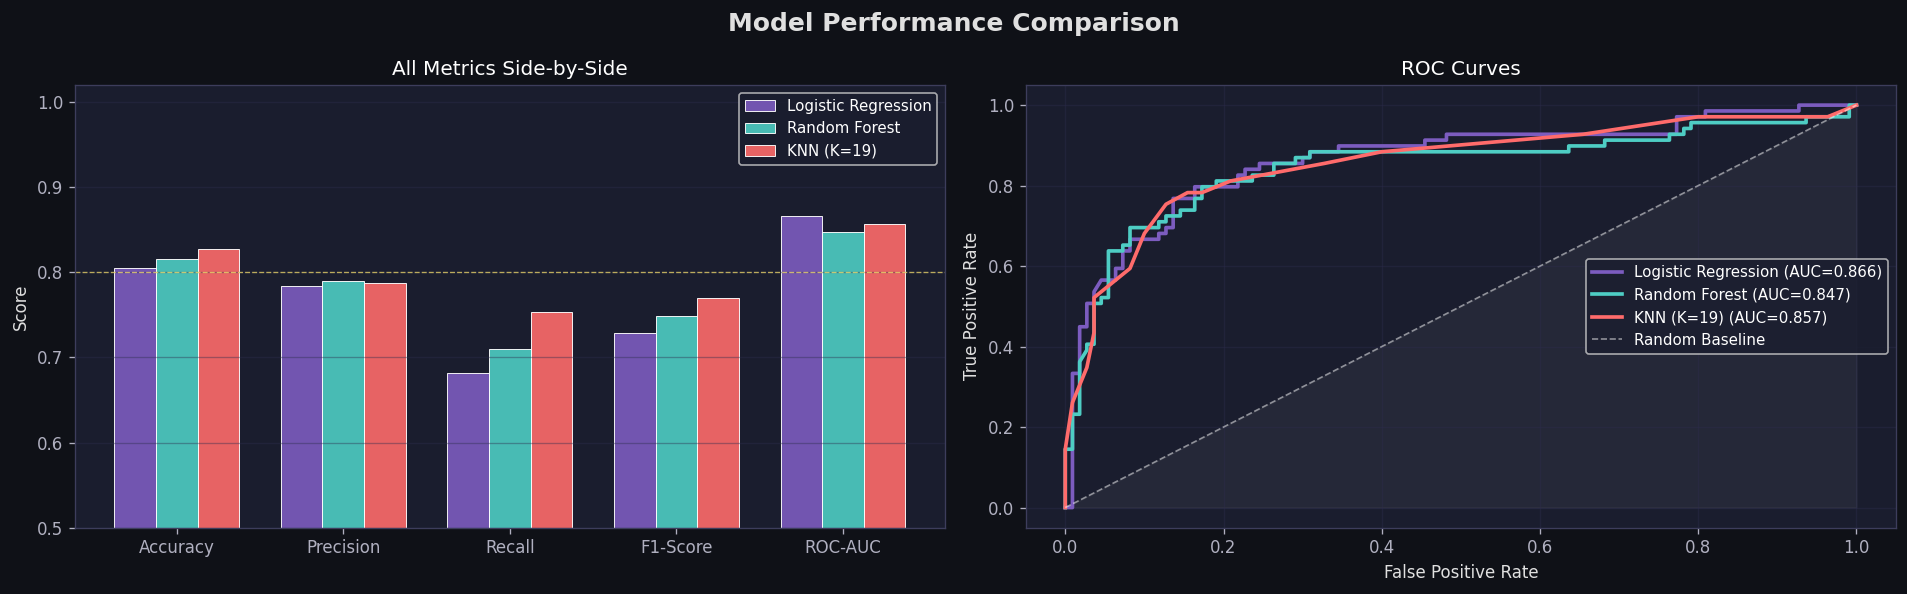

In [22]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = results_df.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

#Bar chart of metrics
x = np.arange(len(metrics))
width = 0.25
for i, (name, color) in enumerate(zip(model_names, PALETTE[:3])):
    vals = [results_df.loc[name, m] for m in metrics]
    bars = axes[0].bar(x + i*width - width, vals, width,
                       label=name, color=color, edgecolor='white', linewidth=0.6, alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.5, 1.02)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics Side-by-Side')
axes[0].legend(facecolor='#1a1d2e', labelcolor='white', fontsize=9)
axes[0].grid(axis='y', alpha=0.4)
axes[0].axhline(0.8, color='#ffe66d', linestyle='--', linewidth=0.8, alpha=0.7)

#ROC Curves
for name, model, color in zip(model_names, models.values(), PALETTE[:3]):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, color=color, linewidth=2.2, label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1], [0,1], 'w--', linewidth=1, alpha=0.5, label='Random Baseline')
axes[1].fill_between([0,1], [0,1], alpha=0.05, color='white')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(facecolor='#1a1d2e', labelcolor='white', fontsize=9)
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()


### Identify the Best Model

In [26]:
best_model_name = results_df['F1-Score'].idxmax()
best_model_obj  = models[best_model_name]
best_row = results_df.loc[best_model_name]

print(f'  BEST MODEL : {best_model_name}')
for metric, value in best_row.items():
    print(f'  {metric:<12} : {value:.4f}')

  BEST MODEL : KNN (K=19)
  Accuracy     : 0.8268
  Precision    : 0.7879
  Recall       : 0.7536
  F1-Score     : 0.7704
  ROC-AUC      : 0.8567
  CV-Acc       : 0.8105


 Confusion Matrix

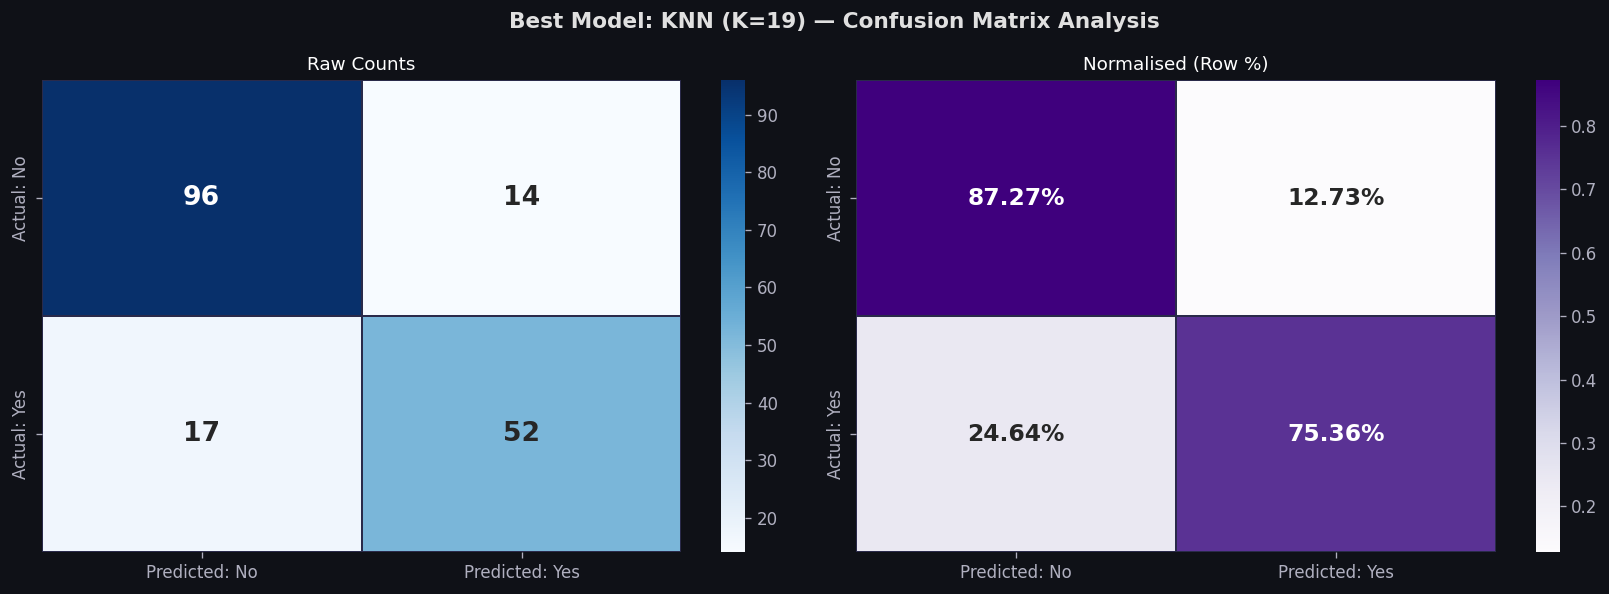

True Negatives  (TN): 96  — Correctly predicted "Did NOT survive"
False Positives (FP): 14  — Incorrectly predicted "Survived" when they didn't
False Negatives (FN): 17  — Incorrectly predicted "Did NOT survive" when they did
True Positives  (TP): 52  — Correctly predicted "Survived"


In [27]:
y_best_pred = best_model_obj.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_best_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Best Model: {best_model_name} — Confusion Matrix Analysis',
             fontsize=13, fontweight='bold')

#Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'],
            linewidths=1, linecolor='#2a2a4a', ax=axes[0],
            annot_kws={'size': 16, 'fontweight': 'bold'})
axes[0].set_title('Raw Counts', fontsize=11)

#  Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Purples',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'],
            linewidths=1, linecolor='#2a2a4a', ax=axes[1],
            annot_kws={'size': 14, 'fontweight': 'bold'})
axes[1].set_title('Normalised (Row %)', fontsize=11)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (TN): {tn}  — Correctly predicted "Did NOT survive"')
print(f'False Positives (FP): {fp}  — Incorrectly predicted "Survived" when they didn\'t')
print(f'False Negatives (FN): {fn}  — Incorrectly predicted "Did NOT survive" when they did')
print(f'True Positives  (TP): {tp}  — Correctly predicted "Survived"')

Classification Report

In [29]:
print(f'Detailed Classification Report — {best_model_name}')
print(classification_report(y_test, y_best_pred,
                              target_names=['Did Not Survive', 'Survived']))

Detailed Classification Report — KNN (K=19)
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.87      0.86       110
       Survived       0.79      0.75      0.77        69

       accuracy                           0.83       179
      macro avg       0.82      0.81      0.82       179
   weighted avg       0.83      0.83      0.83       179



### Feature Importances of Best Model (Random Forest)

Note: KNN (K=19) does not support direct feature importances.
Top features identified by Random Forest earlier:
Sex              0.264441
FarePerPerson    0.137426
Fare             0.136623
Title            0.133003
Age              0.101409
Pclass           0.074516
FamilySize       0.046867
SibSp            0.026998
AgeBin           0.026839
Embarked         0.023721
Parch            0.016206
IsAlone          0.011952


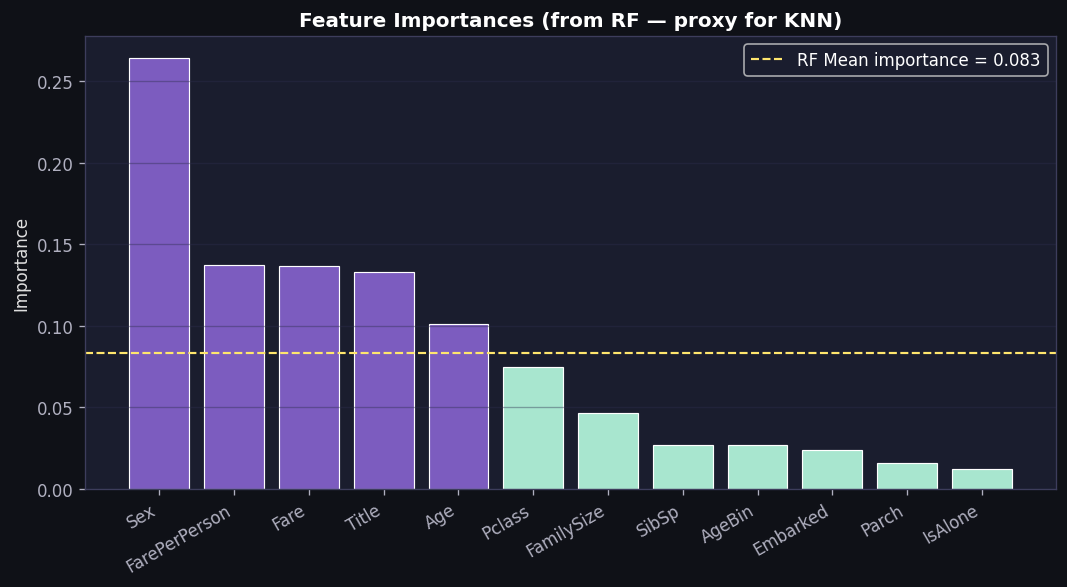

In [30]:
if hasattr(best_model_obj, 'feature_importances_'):
    fi_best = pd.Series(best_model_obj.feature_importances_, index=X.columns)
    fi_best = fi_best.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(fi_best.index, fi_best.values,
                  color=[PALETTE[0] if v > fi_best.mean() else PALETTE[4] for v in fi_best.values],
                  edgecolor='white', linewidth=0.7)
    ax.axhline(fi_best.mean(), color='#ffe66d', linestyle='--', linewidth=1.3,
               label=f'Mean importance = {fi_best.mean():.3f}')
    for bar, val in zip(bars, fi_best.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='white')
    ax.set_title(f'Feature Importances — {best_model_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Importance')
    ax.set_xticks(range(len(fi_best.index)))
    ax.set_xticklabels(fi_best.index, rotation=30, ha='right')
    ax.legend(facecolor='#1a1d2e', labelcolor='white')
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()
elif hasattr(best_model_obj, 'coef_'):
    #show coefficient magnitudes
    coef = pd.Series(np.abs(best_model_obj.coef_[0]), index=X.columns).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(coef.index, coef.values,
           color=[PALETTE[0] if v > coef.mean() else PALETTE[4] for v in coef.values],
           edgecolor='white', linewidth=0.7)
    ax.axhline(coef.mean(), color='#ffe66d', linestyle='--', linewidth=1.3,
               label=f'Mean |coef| = {coef.mean():.3f}')
    ax.set_title(f'Feature Coefficients (|magnitude|) — {best_model_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('|Coefficient|')
    ax.set_xticks(range(len(coef.index)))
    ax.set_xticklabels(coef.index, rotation=30, ha='right')
    ax.legend(facecolor='#1a1d2e', labelcolor='white')
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    # KNN: no direct feature importance — show top features from earlier RF analysis
    print(f'Note: {best_model_name} does not support direct feature importances.')
    print('Top features identified by Random Forest earlier:')
    fi_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(fi_rf.to_string())
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(fi_rf.index, fi_rf.values,
           color=[PALETTE[0] if v > fi_rf.mean() else PALETTE[4] for v in fi_rf.values],
           edgecolor='white', linewidth=0.7)
    ax.axhline(fi_rf.mean(), color='#ffe66d', linestyle='--', linewidth=1.3,
               label=f'RF Mean importance = {fi_rf.mean():.3f}')
    ax.set_title('Feature Importances (from RF — proxy for KNN)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Importance')
    ax.set_xticks(range(len(fi_rf.index)))
    ax.set_xticklabels(fi_rf.index, rotation=30, ha='right')
    ax.legend(facecolor='#1a1d2e', labelcolor='white')
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

In [32]:
print('   FINAL MODEL COMPARISON TABLE')
print(f'{"Model":<25} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1-Score":>9} {"ROC-AUC":>9} {"CV-Acc":>8}')
print('─'*80)
for model_name, row in results_df.iterrows():
    marker = '  ← BEST' if model_name == best_model_name else ''
    print(f'{model_name:<25} {row["Accuracy"]:>9.4f} {row["Precision"]:>10.4f} '
          f'{row["Recall"]:>8.4f} {row["F1-Score"]:>9.4f} {row["ROC-AUC"]:>9.4f} '
          f'{row["CV-Acc"]:>8.4f}{marker}')


   FINAL MODEL COMPARISON TABLE
Model                      Accuracy  Precision   Recall  F1-Score   ROC-AUC   CV-Acc
────────────────────────────────────────────────────────────────────────────────
Logistic Regression          0.8045     0.7833   0.6812    0.7287    0.8661   0.8021
Random Forest                0.8156     0.7903   0.7101    0.7481    0.8473   0.8245
KNN (K=19)                   0.8268     0.7879   0.7536    0.7704    0.8567   0.8105  ← BEST


 Holistic Model Comparison

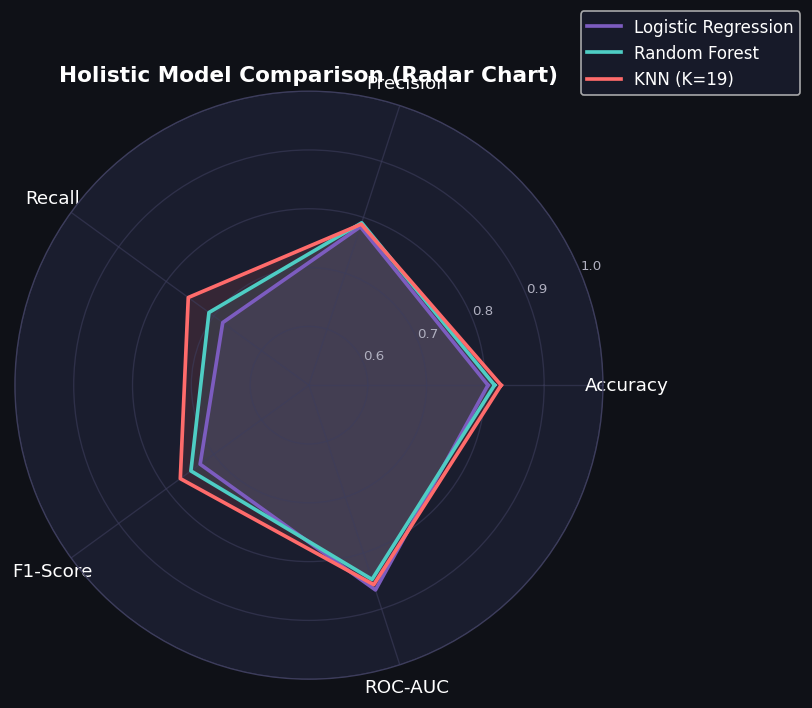

In [33]:
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True),
                        facecolor='#0f1117')
ax.set_facecolor('#1a1d2e')
ax.set_title('Holistic Model Comparison (Radar Chart)',
             fontsize=13, fontweight='bold', color='white')

for name, color in zip(model_names, PALETTE[:3]):
    values = [results_df.loc[name, m] for m in metrics_radar]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2.2, linestyle='solid', label=name)
    ax.fill(angles, values, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, color='white', size=11)
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.6', '0.7', '0.8', '0.9', '1.0'], color='#b0b0c0', size=8)
ax.grid(color='#3d3d5c', alpha=0.6)
ax.spines['polar'].set_color('#3d3d5c')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          facecolor='#1a1d2e', labelcolor='white', fontsize=10)
plt.tight_layout()
plt.show()

In [34]:
print(f'   Best Model  : {best_model_name}')
print(f'   Accuracy    : {results_df.loc[best_model_name, "Accuracy"]:.4f}')
print(f'   F1-Score    : {results_df.loc[best_model_name, "F1-Score"]:.4f}')
print(f'   ROC-AUC     : {results_df.loc[best_model_name, "ROC-AUC"]:.4f}')

   Best Model  : KNN (K=19)
   Accuracy    : 0.8268
   F1-Score    : 0.7704
   ROC-AUC     : 0.8567


Why??

KNN performed well because passengers with similar characteristics (such as age, gender, passenger class, and fare) often had similar survival outcomes. After feature scaling, the model was able to measure the similarity between passengers more effectively, leading to better predictions.

Conclusion
1. KNN (K=19) was the best-performing model in this project.
2. Data preprocessing and feature engineering helped improve the model's performance.
3. Features like Sex, Age, Pclass, Title, and FarePerPerson had the greatest impact on survival prediction.
4. The confusion matrix showed that the model correctly classified most passengers, with only a few incorrect predictions.
5. Overall, this project demonstrates how machine learning can be used to predict Titanic passenger survival with good accuracy.

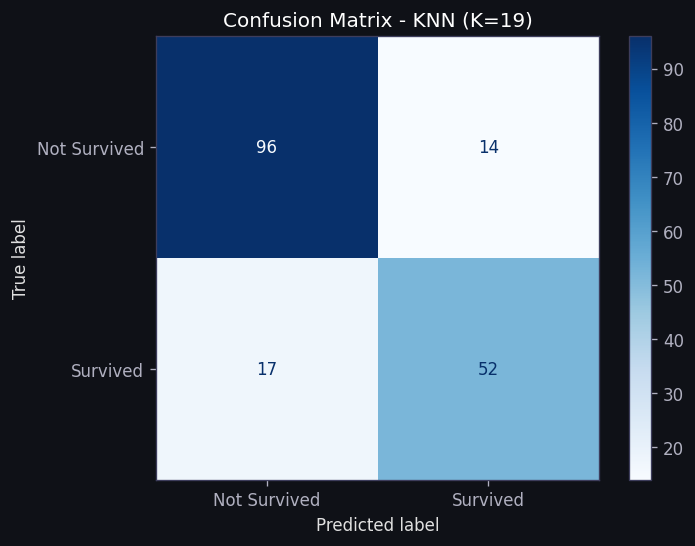

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions from the best model (KNN)
y_pred = knn.predict(X_test_scaled)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    display_labels=["Not Survived", "Survived"]
)

plt.title("Confusion Matrix - KNN (K=19)")
plt.show()